# Density map generation

Generate target density maps from ShanghaiTech head annotations.

Historical exploratory prototype: saved cells/outputs are retained, not final training evidence. The inline adaptive function predates the production single-head fallback and uses truncating coordinates; production code is in src/datasets/density_map.py. Final experiments use corrected fixed maps and cache v2. Do not use this prototype as the training implementation.

In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from scipy.ndimage import gaussian_filter

BASE = Path('../data/raw/ShanghaiTech/part_A/train_data')

img_path = BASE / 'images/IMG_1.jpg'
gt_path = BASE / 'ground-truth/GT_IMG_1.mat'

img = Image.open(img_path)
mat = sio.loadmat(gt_path)
points = mat['image_info'][0, 0][0, 0][0]

w, h = img.size
print(f'Image size: {w}x{h}, heads: {len(points)}')

Image size: 1024x768, heads: 1546


In [2]:
# Fixed-sigma density map
sigma = 15

density = np.zeros((h, w))
for (x, y) in points:
    ix, iy = int(x), int(y)
    if 0 <= ix < w and 0 <= iy < h:
        density[iy, ix] += 1.0

density = gaussian_filter(density, sigma=sigma)

print(f'Density map shape: {density.shape}')
print(f'Sum of density map: {density.sum():.1f}')
print(f'Actual count: {len(points)}')

Density map shape: (768, 1024)
Sum of density map: 1546.0
Actual count: 1546


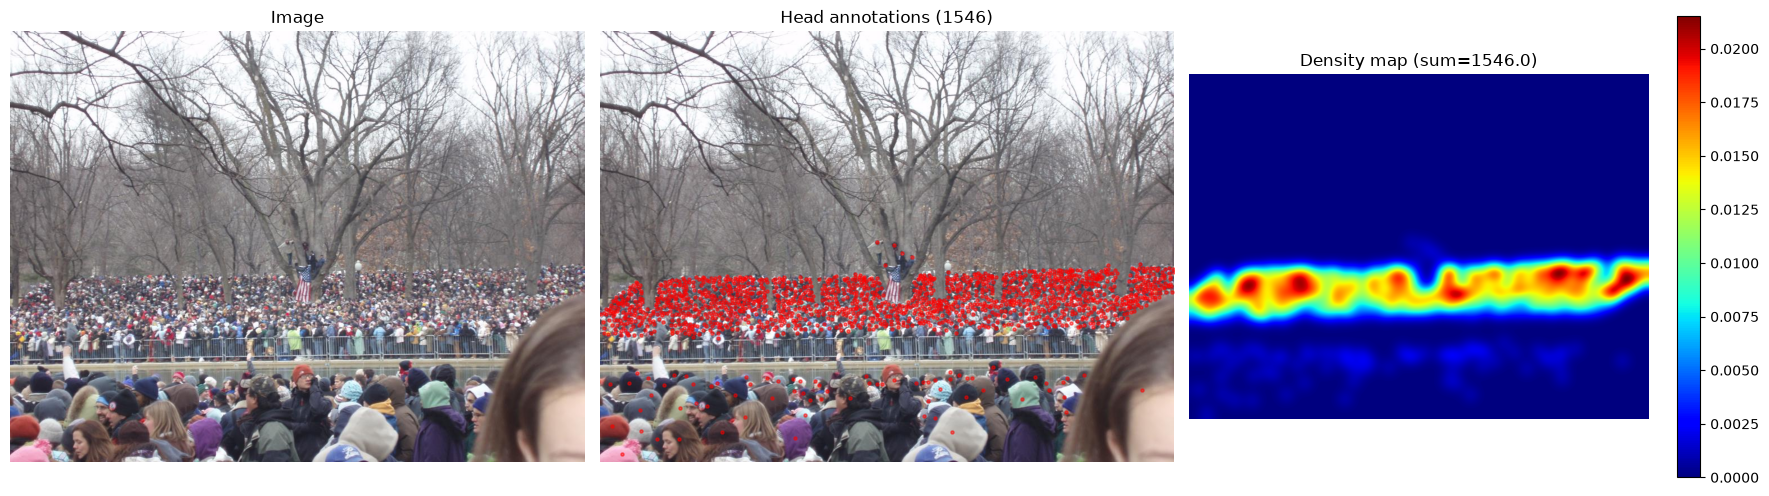

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img)
axes[0].set_title('Image')
axes[0].axis('off')

axes[1].imshow(img)
axes[1].scatter(points[:, 0], points[:, 1], s=5, c='red', alpha=0.5)
axes[1].set_title(f'Head annotations ({len(points)})')
axes[1].axis('off')

im = axes[2].imshow(density, cmap='jet')
axes[2].set_title(f'Density map (sum={density.sum():.1f})')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()

In [5]:
from scipy.spatial import KDTree

def generate_adaptive_density_map(points, h, w, k=4, beta=0.3):
    density = np.zeros((h, w), dtype=np.float32)
    if len(points) == 0:
        return density

    tree = KDTree(points)

    for (x, y) in points:
        distances, _ = tree.query((x, y), k=min(k + 1, len(points)))
        # Skip distance to self (distances[0] == 0)
        avg_dist = np.mean(distances[1:])
        sigma = beta * avg_dist

        if sigma < 1e-5:
            sigma = 2.0  # fallback for isolated points

        # Add Gaussian centered at (x, y)
        radius = int(3 * sigma)
        for dy in range(-radius, radius + 1):
            for dx in range(-radius, radius + 1):
                yy = int(y) + dy
                xx = int(x) + dx
                if 0 <= yy < h and 0 <= xx < w:
                    density[yy, xx] += (1 / (2 * np.pi * sigma**2)) * np.exp(-(dx**2 + dy**2) / (2 * sigma**2))

    return density

adaptive_density = generate_adaptive_density_map(points, h, w)

print(f'Adaptive density map shape: {adaptive_density.shape}')
print(f'Sum: {adaptive_density.sum():.1f}')
print(f'Actual count: {len(points)}')
print(f'Difference: {abs(adaptive_density.sum() - len(points)):.1f}')


Adaptive density map shape: (768, 1024)
Sum: 1536.4
Actual count: 1546
Difference: 9.6


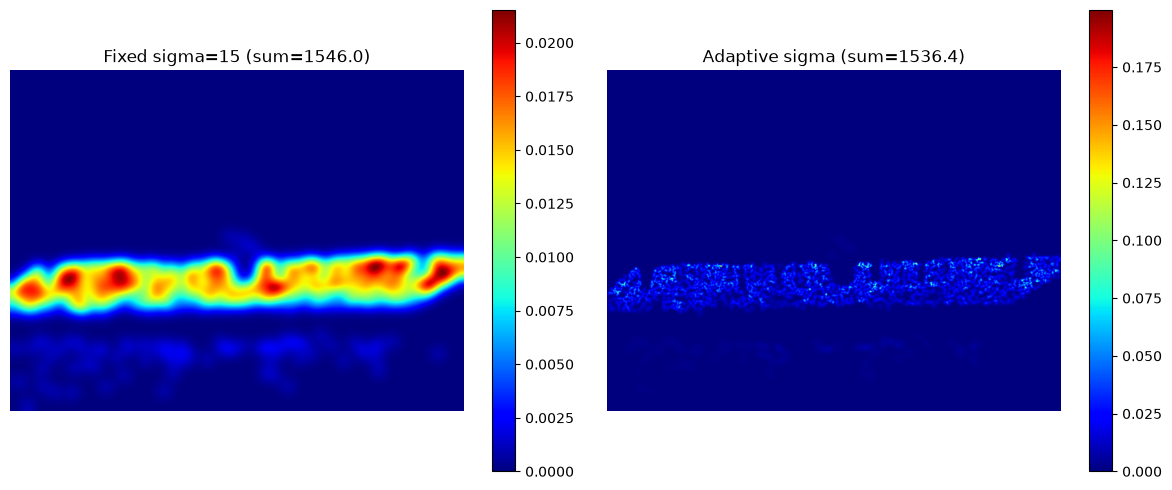

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(density, cmap='jet')
axes[0].set_title(f'Fixed sigma=15 (sum={density.sum():.1f})')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(adaptive_density, cmap='jet')
axes[1].set_title(f'Adaptive sigma (sum={adaptive_density.sum():.1f})')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()

Part B IMG_1: size=1024x768, heads=233
Fixed sum: 233.0
Adaptive sum: 223.8


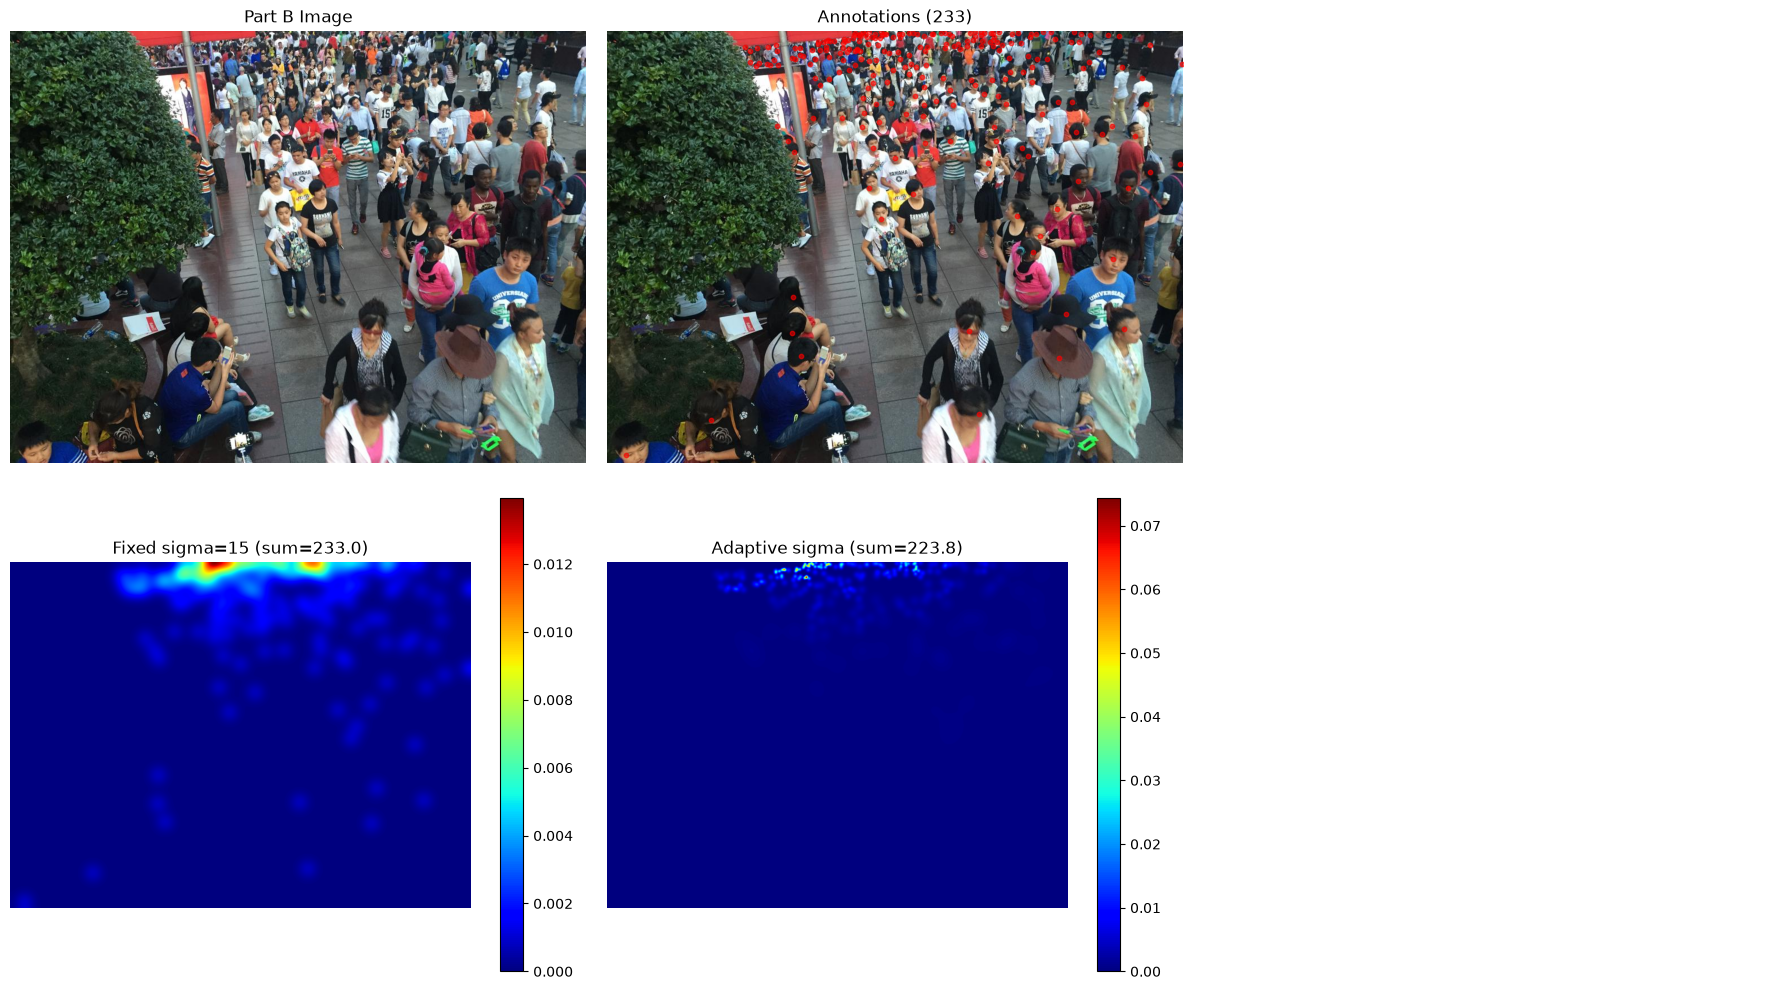

In [6]:
# Try on Part B
BASE_B = Path('../data/raw/ShanghaiTech/part_B/train_data')

img_path_b = BASE_B / 'images/IMG_1.jpg'
gt_path_b = BASE_B / 'ground-truth/GT_IMG_1.mat'

img_b = Image.open(img_path_b)
mat_b = sio.loadmat(gt_path_b)
points_b = mat_b['image_info'][0, 0][0, 0][0]
w_b, h_b = img_b.size

density_b = np.zeros((h_b, w_b))
for (x, y) in points_b:
    ix, iy = int(x), int(y)
    if 0 <= ix < w_b and 0 <= iy < h_b:
        density_b[iy, ix] += 1.0
density_b = gaussian_filter(density_b, sigma=15)

adaptive_density_b = generate_adaptive_density_map(points_b, h_b, w_b)

print(f'Part B IMG_1: size={w_b}x{h_b}, heads={len(points_b)}')
print(f'Fixed sum: {density_b.sum():.1f}')
print(f'Adaptive sum: {adaptive_density_b.sum():.1f}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].imshow(img_b)
axes[0, 0].set_title('Part B Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_b)
axes[0, 1].scatter(points_b[:, 0], points_b[:, 1], s=10, c='red', alpha=0.6)
axes[0, 1].set_title(f'Annotations ({len(points_b)})')
axes[0, 1].axis('off')

axes[0, 2].axis('off')

im1 = axes[1, 0].imshow(density_b, cmap='jet')
axes[1, 0].set_title(f'Fixed sigma=15 (sum={density_b.sum():.1f})')
axes[1, 0].axis('off')
plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(adaptive_density_b, cmap='jet')
axes[1, 1].set_title(f'Adaptive sigma (sum={adaptive_density_b.sum():.1f})')
axes[1, 1].axis('off')
plt.colorbar(im2, ax=axes[1, 1])

axes[1, 2].axis('off')

plt.tight_layout()